# Projet n°1 L2 : machine learning

**Data Collection & Data Analysis**: Julien Arsena

**Machine Learning**: Julien Arsena 

**Date**: October, 2025

Movie posters play a crucial role in the marketing of films, often shaping the audience's expectations and interest. 
The goal of this project is to predict the dominant color of a movie poster based on its metadata, such as genre, budget, language, the length of the title and year of release. Since the target variable is categorical (the color of the movie poster), this is a multiclass classification goal.


**Objective** : Predict the color of a movie poster by a the budget, the original language, the genre and the length of the title of the films. 

## 1. Library import

In [21]:
# Computing libraries
import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score 

# Graphical libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Modelling libraries
from sklearn.linear_model import LogisticRegression # Logistic regression

In [22]:
# Function to plot the coefficients of the regressions

# Code fully generated by GPT-4
def plot_coef(coef) :
    # Sort the coefficients by their absolute values
    sorted_coef = coef.abs().sort_values()

    # Get the original coefficients for coloring
    original_sorted_coef = coef.loc[sorted_coef.index]

    # Create a scatter plot with bars
    plt.figure(figsize=(8, 8))

    # Plot positive coefficients in blue, negative coefficients in red, and near-zero coefficients in grey
    colors = [
        'grey' if abs(coef) < 1e-08 else 'blue' if coef > 0 else 'red'
        for coef in original_sorted_coef
    ]

    plt.scatter(sorted_coef.values, sorted_coef.index, color=colors, zorder = 5)

    # Plot lines from the origin to the dots
    for i in range(len(sorted_coef)):
        plt.plot([0, sorted_coef.values[i]], [i, i], color='skyblue', lw = 2)

    plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
    plt.xlabel('Absolute Coefficient Value')
    plt.ylabel('Feature')
    plt.title('Regression Coefficients (Absolute Values)')

    plt.show()

## 2. Data import

In [23]:
df = pd.read_csv("projetn1.csv")
display(df)

,Unnamed: 0,title,image_url,year,genre,budget,original_language,couleur_1,hex_1,couleur_2,hex_2,couleur_3,hex_3,couleur_4,hex_4,couleur_5,hex_5
0,0,57 Seconds,https://datasets-server.huggingface.co/cached-...,2023,"{'id': 53, 'name': 'Thriller'}|{'id': 878, 'na...",0,en,blanc,#f1eee9,gris foncé,#23242a,bleu,#3f474f,gris,#737b7e,gris clair,#c0b6ae
1,1,Mission: Impossible - Dead Reckoning Part One,https://datasets-server.huggingface.co/cached-...,2023,"{'id': 28, 'name': 'Action'}|{'id': 53, 'name'...",291000000,en,blanc,#f8f6f0,gris foncé,#2d292d,rouge,#a35f50,gris clair,#bdb0ae,bleu,#586f8a
2,2,Expend4bles,https://datasets-server.huggingface.co/cached-...,2023,"{'id': 28, 'name': 'Action'}|{'id': 12, 'name'...",100000000,en,rouge foncé,#150706,rouge,#ad231c,rouge foncé,#5e1c1c,jaune clair,#d2962e,vert clair,#5fcd7f
3,3,Sound of Freedom,https://datasets-server.huggingface.co/cached-...,2023,"{'id': 28, 'name': 'Action'}|{'id': 18, 'name'...",15000000,en,blanc,#fef6ee,noir,#0e0d0f,gris foncé,#3f3935,gris,#7c726a,gris clair,#bdb5ab
4,4,Nowhere,https://datasets-server.huggingface.co/cached-...,2023,"{'id': 53, 'name': 'Thriller'}|{'id': 18, 'nam...",0,es,gris foncé,#293130,noir,#0e0f0f,gris foncé,#495451,gris,#808373,jaune,#bdad8e
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2995,Mom,https://datasets-server.huggingface.co/cached-...,2017,"{'id': 80, 'name': 'Crime'}|{'id': 18, 'name':...",0,hi,turquoise foncé,#102129,turquoise,#364345,gris,#888076,gris clair,#d7d6d2,rouge,#bf383e
2996,2996,In the Morning of La Petite Mort,https://datasets-server.huggingface.co/cached-...,2023,"{'id': 18, 'name': 'Drama'}",0,zh,rose foncé,#22181d,rose,#504147,gris,#afa3a5,gris,#7d7276,gris clair,#d5d0d6
2997,2997,Deadstream,https://datasets-server.huggingface.co/cached-...,2022,"{'id': 27, 'name': 'Horror'}|{'id': 35, 'name'...",0,en,noir,#100703,marron,#291b10,marron,#56412e,jaune,#b09a5c,orange,#b24017
2998,2998,Sansón and Me,https://datasets-server.huggingface.co/cached-...,2023,"{'id': 99, 'name': 'Documentary'}",0,es,turquoise,#3e7171,noir,#090508,rose foncé,#462d36,rose clair,#d11392,orange,#a67257


## 3. Data manipulation

In [24]:
# Extract the genre
df["genre"] = df["genre"].apply(
    lambda x: "|".join([ast.literal_eval(g)["name"] 
                        for g in str(x).split("|") if "name" in g])
)

# Remove rows where budget == 0
df = df[df["budget"] != 0]
log_Budget = np.log10(df['budget'])
df['log_budget'] = log_Budget


In [25]:
# Add a "title_length" column (length of the title)
df['title_length'] = df['title'].astype(str).apply(len)

In [26]:
# Map your current labels to simple color families
family_map = {
    "rouge": "red", "rouge clair": "red", "rouge foncé": "red",
    "orange": "yellow", "orange clair": "yellow", "marron": "red", "orange foncé": "red",
    "jaune": "yellow", "jaune clair": "yellow", "jaune foncé": "yellow",
    "vert": "green", "vert clair": "green", "vert foncé": "green",
    "turquoise": "green", "turquoise clair": "green", "turquoise foncé": "green",
    "bleu": "blue", "bleu clair": "blue", "bleu foncé": "blue",
    "violet": "red", "violet clair": "red", "violet foncé": "red",
    "magenta": "red", "rose": "red", "rose clair": "red", "rose foncé": "red",
    "magenta clair": "red", "magenta foncé": "red",
    "gris": "gray", "gris clair": "gray", "gris foncé": "gray",
    "noir": "black",
    "blanc": "white"
}
df["couleur_1"] = df["couleur_1"].map(family_map).fillna(df["couleur_1"])


In [27]:
display(df)

,Unnamed: 0,title,image_url,year,genre,budget,original_language,couleur_1,hex_1,couleur_2,hex_2,couleur_3,hex_3,couleur_4,hex_4,couleur_5,hex_5,log_budget,title_length
1,1,Mission: Impossible - Dead Reckoning Part One,https://datasets-server.huggingface.co/cached-...,2023,Action|Thriller,291000000,en,white,#f8f6f0,gris foncé,#2d292d,rouge,#a35f50,gris clair,#bdb0ae,bleu,#586f8a,8.463893,45
2,2,Expend4bles,https://datasets-server.huggingface.co/cached-...,2023,Action|Adventure|Thriller,100000000,en,red,#150706,rouge,#ad231c,rouge foncé,#5e1c1c,jaune clair,#d2962e,vert clair,#5fcd7f,8.000000,11
3,3,Sound of Freedom,https://datasets-server.huggingface.co/cached-...,2023,Action|Drama,15000000,en,white,#fef6ee,noir,#0e0d0f,gris foncé,#3f3935,gris,#7c726a,gris clair,#bdb5ab,7.176091,16
5,5,The Nun II,https://datasets-server.huggingface.co/cached-...,2023,Horror|Mystery|Thriller,38500000,en,black,#010000,marron,#150e09,marron,#312417,marron,#5b4934,gris,#afa9a1,7.585461,10
7,7,Gran Turismo,https://datasets-server.huggingface.co/cached-...,2023,Adventure|Action|Drama,60000000,en,black,#131314,rouge foncé,#56433e,orange,#bf8454,bleu,#5e7389,gris clair,#d7d6cd,7.778151,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2988,2988,Martin Eden,https://datasets-server.huggingface.co/cached-...,2019,Romance|Drama,3800000,it,gray,#cce0e7,noir,#120d12,gris clair,#a9c1ca,rouge foncé,#53393b,rouge,#a9504d,6.579784,11
2989,2989,Retribution,https://datasets-server.huggingface.co/cached-...,2015,Thriller|Drama,4670099,es,black,#050704,blanc,#eef0e9,vert foncé,#4c513b,jaune,#aa9a7c,turquoise clair,#5cc8d1,6.669326,11
2990,2990,Just Getting Started,https://datasets-server.huggingface.co/cached-...,2017,Action|Comedy,22000000,en,gray,#ced7c8,gris,#6d6d66,orange,#c48f58,jaune clair,#f3cb76,rouge foncé,#2f1616,7.342423,20
2991,2991,My King,https://datasets-server.huggingface.co/cached-...,2015,Drama|Romance,10600000,fr,black,#120b0a,marron,#623a29,orange,#a36c4f,orange clair,#dab698,blanc,#faf4ec,7.025306,7


In [28]:
df.describe()

,Unnamed: 0,year,budget,log_budget,title_length
count,1382.000000,1382.000000,1.382000e+03,1382.000000,1382.000000
mean,1273.845876,2006.961650,4.025712e+07,7.203061,15.535456
std,821.408101,16.593512,5.115444e+07,0.802868,9.025499
min,1.000000,1902.000000,1.000000e+00,0.000000,2.000000
25%,566.500000,2000.000000,7.000000e+06,6.845098,9.000000
50%,1173.500000,2013.000000,2.000000e+07,7.301030,13.000000
75%,1927.750000,2019.000000,5.000000e+07,7.698970,19.000000
max,2992.000000,2023.000000,3.400000e+08,8.531479,72.000000


## 4. Monovariate description

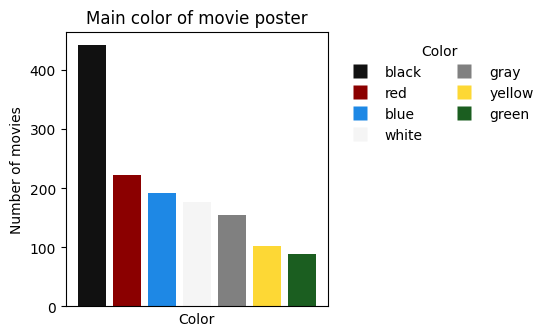

In [29]:
# Map name -> hex (add your shades if needed)

color_hex = {
    "white":"#f5f5f5",
    "black":"#111111",
    "grey":"#9e9e9e",
    "red":"#8b0000",
    "orange":"#fb8c00",
    "brown":"#795548",
    "yellow":"#fdd835",
    "green":"#1b5e20",
    "blue":"#1e88e5",
    "purple":"#8e24aa",
    "prink":"#d81b60",
}

fig = plt.figure(figsize=(8, 6), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])


ax1 = fig.add_subplot(gs[0, 0])
c1 = df['couleur_1'].value_counts()
labels1 = c1.index
colors1 = [color_hex.get(lbl, "#808080") for lbl in labels1]
bars1 = ax1.bar(labels1, c1.values, color=colors1)
ax1.set_xlabel("Color")
ax1.set_ylabel("Number of movies")
ax1.set_title("Main color of movie poster")
ax1.set_xticks([])  # no labels under the bars
handles1 = [plt.Line2D([0],[0], marker='s', linestyle='', markersize=10,
                       markerfacecolor=color_hex.get(lbl,"#808080"),
                       markeredgecolor='none', label=lbl) for lbl in labels1[:12]]
ax1.legend(handles=handles1, title="Color",
           bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2, frameon=False)




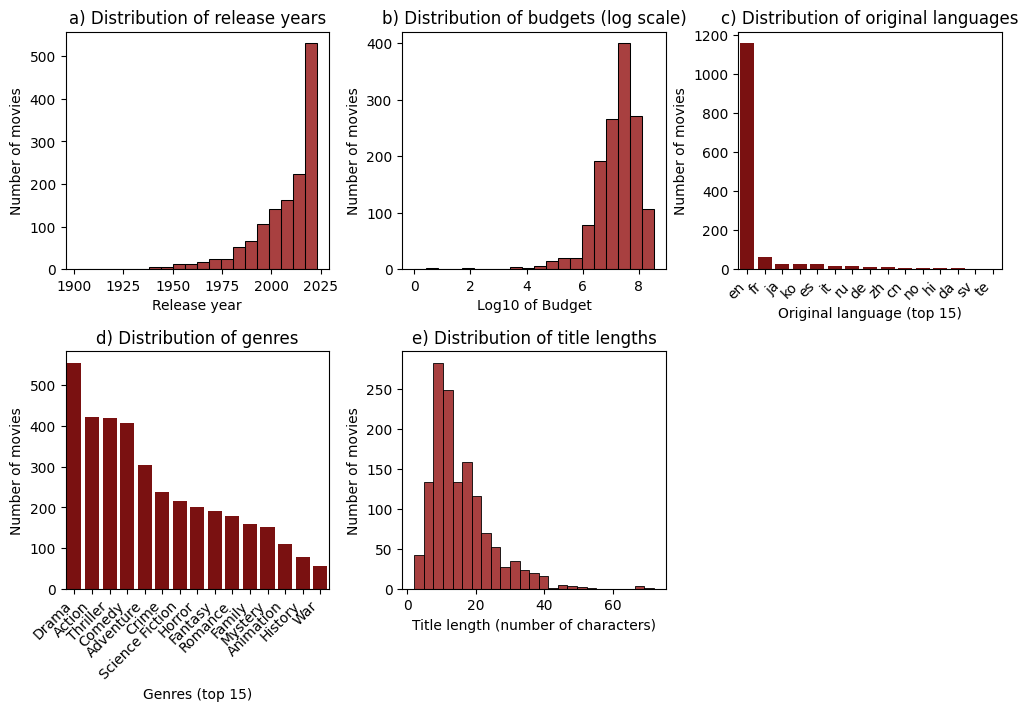

In [30]:
fig2 = plt.figure(figsize=(10, 7), constrained_layout=True)

# 1️) Release year
plt.subplot(2, 3, 1)
sns.histplot(df['year'], bins=20, color="darkred")
plt.xlabel("Release year")
plt.ylabel("Number of movies")
plt.title("a) Distribution of release years")

# 2️) Budget (log10)
plt.subplot(2, 3, 2)
sns.histplot(df['log_budget'], bins=20, color="darkred")
plt.xlabel("Log10 of Budget")
plt.ylabel("Number of movies")
plt.title("b) Distribution of budgets (log scale)")

# 3️) Original language (Top 15)
plt.subplot(2, 3, 3)
langs = df['original_language'].value_counts().head(15)
sns.barplot(x=langs.index, y=langs.values, color="darkred")
plt.xlabel("Original language (top 15)")
plt.ylabel("Number of movies")
plt.title("c) Distribution of original languages")
plt.xticks(rotation=45, ha="right")

# 4️) Genre (Top 15)
plt.subplot(2, 3, 4)
genres = df['genre'].str.split('|').explode().value_counts().head(15)
sns.barplot(x=genres.index, y=genres.values, color="darkred")
plt.xlabel("Genres (top 15)")
plt.ylabel("Number of movies")
plt.title("d) Distribution of genres")
plt.xticks(rotation=45, ha="right")

# 5️) Title length
plt.subplot(2, 3, 5)
sns.histplot(df['title_length'], bins=25, color="darkred")
plt.xlabel("Title length (number of characters)")
plt.ylabel("Number of movies")
plt.title("e) Distribution of title lengths")

plt.show()


In [31]:
df = df[['year', 'budget', 'log_budget', 'original_language', 'genre', 'title_length', 'couleur_1',]]
df = df.dropna()
df_unstandardized = df.copy()
df

,year,budget,log_budget,original_language,genre,title_length,couleur_1
1,2023,291000000,8.463893,en,Action|Thriller,45,white
2,2023,100000000,8.000000,en,Action|Adventure|Thriller,11,red
3,2023,15000000,7.176091,en,Action|Drama,16,white
5,2023,38500000,7.585461,en,Horror|Mystery|Thriller,10,black
7,2023,60000000,7.778151,en,Adventure|Action|Drama,12,black
...,...,...,...,...,...,...,...
2988,2019,3800000,6.579784,it,Romance|Drama,11,gray
2989,2015,4670099,6.669326,es,Thriller|Drama,11,black
2990,2017,22000000,7.342423,en,Action|Comedy,20,gray
2991,2015,10600000,7.025306,fr,Drama|Romance,7,black


## 5. Data standardization

In [32]:
# Select only numeric columns
num_cols = df.select_dtypes(include='number').columns

# Standardization (mean = 0, std = 1)
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df


,year,budget,log_budget,original_language,genre,title_length,couleur_1
1,0.967107,4.896996,1.568985,en,Action|Thriller,3.265271,white
2,0.967107,1.165873,0.991619,en,Action|Adventure|Thriller,-0.502820,red
3,0.967107,-0.494574,-0.033827,en,Action|Drama,0.051311,white
5,0.967107,-0.035509,0.475679,en,Horror|Mystery|Thriller,-0.613646,black
7,0.967107,0.384487,0.715503,en,Adventure|Action|Drama,-0.391993,black
...,...,...,...,...,...,...,...
2988,0.725637,-0.713362,-0.775998,it,Romance|Drama,-0.502820,gray
2989,0.484167,-0.696365,-0.664552,es,Thriller|Drama,-0.502820,black
2990,0.604902,-0.357831,0.173191,en,Action|Comedy,0.494616,gray
2991,0.484167,-0.580526,-0.221496,fr,Drama|Romance,-0.946124,black


## 6. Train/test split

In [33]:
# multiclass target: dominant color
y = df["couleur_1"]

# X
X = pd.concat([
    df[["year", "log_budget", "title_length"]],
    pd.get_dummies(df["original_language"], prefix="lang"),
    df["genre"].str.get_dummies(sep="|")
], axis=1)

# 1) Safe stratify: group very rare classes only for stratify
counts = y.value_counts()
rare_classes = counts[counts < 2].index  # < 2 occurrences cause issues
y_strat = y.where(~y.isin(rare_classes), "Other")

# 2) Split using indices (keep the true labels y)
try:
    X_train, X_test, idx_train, idx_test = train_test_split(
        X, df.index, test_size=0.25, random_state=42, stratify=y_strat
    )
except ValueError as e:
    print("Stratify impossible (still too many rare classes) -> split without stratify.")
    X_train, X_test, idx_train, idx_test = train_test_split(
        X, df.index, test_size=0.25, random_state=42
    )

y_train = y.loc[idx_train]
y_test  = y.loc[idx_test]

print("X_train/X_test size:", X_train.shape, X_test.shape)
print("Distribution (train):"); print(y_train.value_counts().head(10))
print("Distribution (test) :"); print(y_test.value_counts().head(10))


X_train/X_test size: (1033, 43) (345, 43)
Distribution (train):
couleur_1
black     332
red       166
blue      144
white     133
gray      115
yellow     77
green      66
Name: count, dtype: int64
Distribution (test) :
couleur_1
black     111
red        56
blue       48
white      44
gray       39
yellow     25
green      22
Name: count, dtype: int64


## 7. Modelling

### 7.1 Logistic regression

#### 7.1.1 Train

In [34]:
# Performing Logistic Regression
reg = LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced")
reg.fit(X_train, y_train)

coef = pd.Series(reg.coef_[0], index=X.columns)

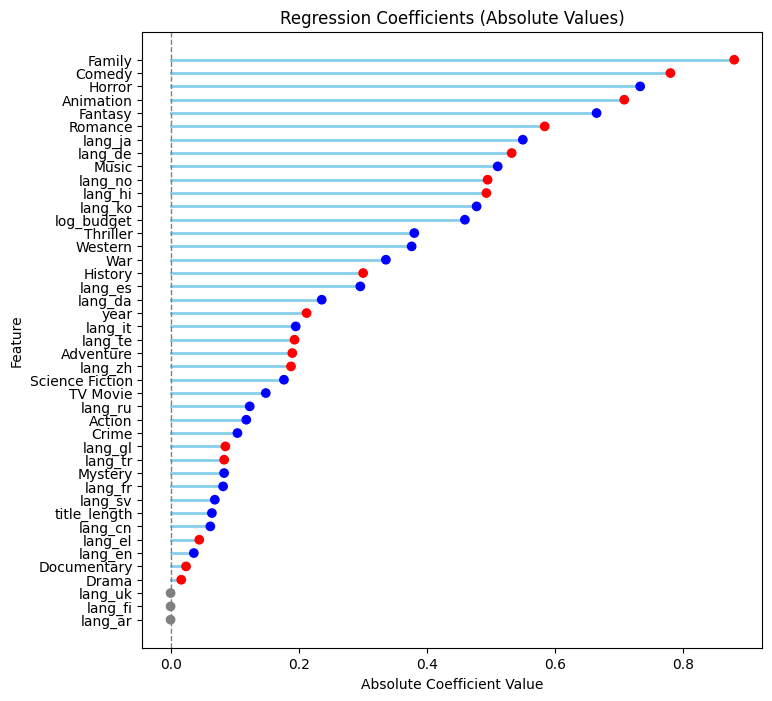

In [35]:
plot_coef(coef)

In [36]:
# TRAIN predictions
y_pred = reg.predict(X_train)

# Confusion matrix (multiclass)
labels = list(reg.classes_)
cm = confusion_matrix(y_train, y_pred, labels=labels)
cm_df = pd.DataFrame(cm,
                     index=[f"Actual {c}"    for c in labels],
                     columns=[f"Predicted {c}" for c in labels])

print("Confusion Matrix (Train) — Logistic Regression (multiclass)")
cm_df
labels = list(reg.classes_)
cm = confusion_matrix(y_train, y_pred, labels=labels)
cm_df = pd.DataFrame(cm,
                     index=[f"Actual {c}"    for c in labels],
                     columns=[f"Predicted {c}" for c in labels])

print("Confusion Matrix (Train) — Logistic Regression (multiclass)")
cm_df


Confusion Matrix (Train) — Logistic Regression (multiclass)
Confusion Matrix (Train) — Logistic Regression (multiclass)


,Predicted black,Predicted blue,Predicted gray,Predicted green,Predicted red,Predicted white,Predicted yellow
Actual black,181,23,18,26,15,45,24
Actual blue,36,30,16,18,7,15,22
Actual gray,25,8,23,12,6,19,22
Actual green,13,5,0,26,4,6,12
Actual red,39,12,19,22,18,27,29
Actual white,20,7,7,11,5,59,24
Actual yellow,9,5,5,8,1,19,30


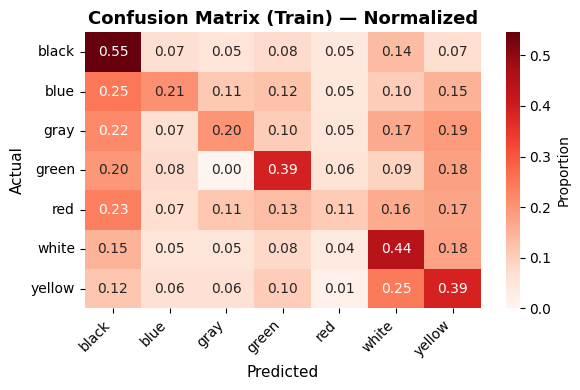

In [37]:
# Normalized confusion matrix
cm = confusion_matrix(y_train, y_pred, labels=labels, normalize="true")

# Heatmap with annotations and colorbar
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Reds",
            xticklabels=labels, yticklabels=labels,
            cbar=True, cbar_kws={'label': 'Proportion'})

plt.title("Confusion Matrix (Train) — Normalized", fontsize=13, fontweight="bold")
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("Actual", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [38]:
print("Accuracy score on train set:")
accuracy_score(y_train, y_pred)

Accuracy score on train set:


0.3552758954501452

#### 7.1.2 Test

In [39]:
# Test the logistic regression (multiclass)
y_pred = reg.predict(X_test)

# Confusion matrix
labels = list(reg.classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm,
                     index=[f"Actual {c}" for c in labels],
                     columns=[f"Predicted {c}" for c in labels])

# Display the confusion matrix
print("Confusion Matrix (Test):")
cm_df



Confusion Matrix (Test):


,Predicted black,Predicted blue,Predicted gray,Predicted green,Predicted red,Predicted white,Predicted yellow
Actual black,55,11,8,6,4,19,8
Actual blue,12,11,4,9,2,4,6
Actual gray,11,5,1,6,3,7,6
Actual green,4,1,1,4,3,6,3
Actual red,18,10,2,6,3,6,11
Actual white,7,3,4,4,0,18,8
Actual yellow,4,5,5,1,1,6,3


In [40]:
print("Accuracy score on test set:")
accuracy_score(y_test, y_pred)

Accuracy score on test set:


0.2753623188405797

#### 7.1.3 Bias/Variance diagnostic

The model achieves 35.52% accuracy on the training set, but its accuracy drops to 27.53% on the test set.
This noticeable gap suggests a relatively high variance, indicating that the model may be overfitting the training data and struggling to generalize well to unseen examples.

Moreover, the low overall accuracy implies that the model also suffers from bias, as its predictions fail to capture the underlying structure of the data effectively.

In other words, this model faces both high bias and moderate variance, which makes its performance limited in both training and generalization.

### 7.2 Logistic regression with L1 regularization (LASSO)

#### 7.2.1 Train

c:\Users\arsen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


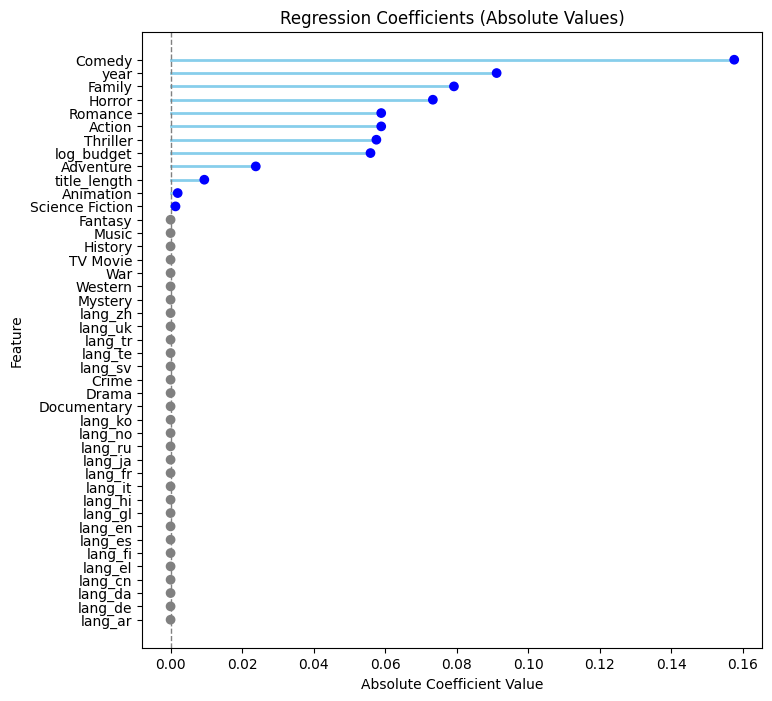

In [41]:
# Train Logistic Regression with L1 regularization (LASSO)
reg = LogisticRegression(penalty='l1', solver='saga', C=0.1,
                         multi_class='multinomial', max_iter=5000)
reg.fit(X_train, y_train)

# Coefficients (multiclass) -> aggregated as mean absolute importance
coef = pd.Series(np.mean(np.abs(reg.coef_), axis=0), index=X.columns)
plot_coef(coef)


In [42]:
# Train the logistic regression
y_pred = reg.predict(X_train)

# Confusion matrix (multiclasse)
labels = list(reg.classes_)
cm = confusion_matrix(y_train, y_pred, labels=labels)
cm_df = pd.DataFrame(cm,
                     index=[f'Actual {c}' for c in labels],
                     columns=[f'Predicted {c}' for c in labels])

print("Confusion Matrix (Train):")
cm_df


Confusion Matrix (Train):


,Predicted black,Predicted blue,Predicted gray,Predicted green,Predicted red,Predicted white,Predicted yellow
Actual black,309,4,1,0,8,10,0
Actual blue,114,4,1,0,14,11,0
Actual gray,82,5,1,0,14,13,0
Actual green,42,3,0,0,14,7,0
Actual red,134,6,0,0,12,14,0
Actual white,81,6,0,0,9,37,0
Actual yellow,44,4,0,0,12,17,0


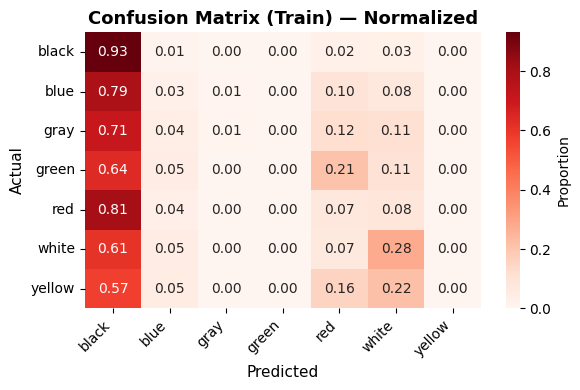

In [43]:
# Normalized confusion matrix
cm = confusion_matrix(y_train, y_pred, labels=labels, normalize="true")

# Heatmap with annotations and colorbar
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Reds",
            xticklabels=labels, yticklabels=labels,
            cbar=True, cbar_kws={'label': 'Proportion'})

plt.title("Confusion Matrix (Train) — Normalized", fontsize=13, fontweight="bold")
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("Actual", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [44]:
print("Accuracy score on train set:")
accuracy_score(y_train, y_pred)

Accuracy score on train set:


0.3514036786060019

#### 7.2.2 Test

In [45]:
# Test the logistic regression (L1 - multinomial)
y_pred = reg.predict(X_test)

# Conflusion matrix
labels = list(reg.classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm,
                     index=[f'Actual {c}' for c in labels],
                     columns=[f'Predicted {c}' for c in labels])

# Display the confusion matrix
print("Confusion Matrix (Test):")
cm_df


Confusion Matrix (Test):


,Predicted black,Predicted blue,Predicted gray,Predicted green,Predicted red,Predicted white,Predicted yellow
Actual black,101,0,0,0,4,6,0
Actual blue,33,1,0,0,5,9,0
Actual gray,29,3,0,0,3,4,0
Actual green,15,1,0,0,5,1,0
Actual red,45,3,0,0,7,1,0
Actual white,24,1,1,0,8,10,0
Actual yellow,20,1,1,0,0,3,0


In [46]:
print("Accuracy score on test set:")
accuracy_score(y_test, y_pred)

Accuracy score on test set:


0.34492753623188405

#### 7.2.3 Bias/Variance diagnostic

The model achieves 35.14% accuracy on the training set and 34.49% on the test set.
The small difference between training and test accuracies suggests that the model has low variance and generalizes relatively consistently.

However, the low accuracy on both sets points to a significant bias, likely due to the regularization strength imposed by LASSO, which penalizes many coefficients and leads to underfitting.

Therefore, the LASSO regression exhibits low variance but high bias, trading model complexity for stability.

### 7.3. Logistic regression with L2 regularization (RIDGE)

#### 7.3.1. Train

c:\Users\arsen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


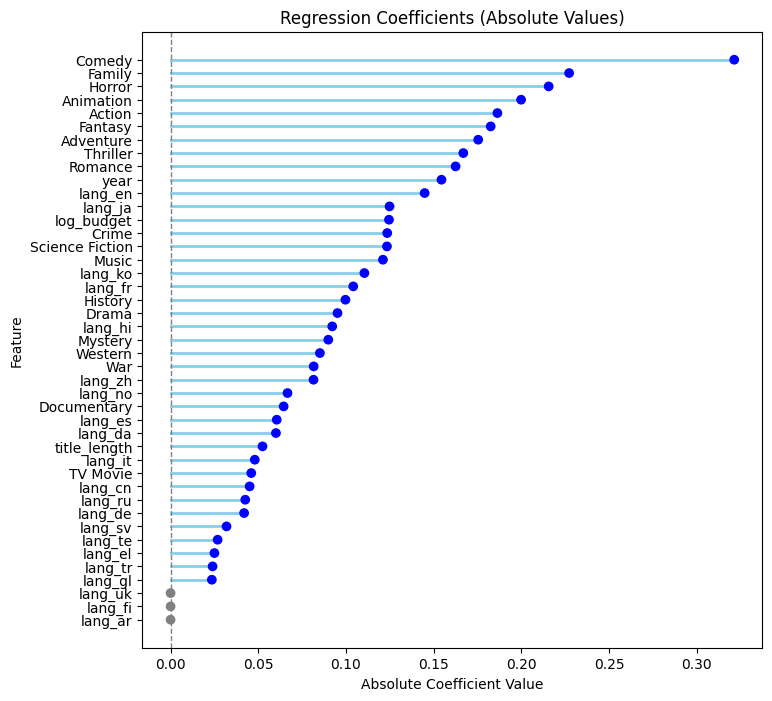

In [47]:
# Performing Logistic Regression with L2 regularization
reg = LogisticRegression(penalty='l2', solver='lbfgs', C=0.1,
                         multi_class='multinomial', max_iter=5000)
reg.fit(X_train, y_train)

# Coefficients (multiclasse)
coef = pd.Series(np.mean(np.abs(reg.coef_), axis=0), index=X.columns)
plot_coef(coef)


In [48]:
# Train the logistic regression
y_pred = reg.predict(X_train)

# Conflusion matrix
labels = list(reg.classes_)
cm = confusion_matrix(y_train, y_pred, labels=labels)
cm_df = pd.DataFrame(cm,
                     index=[f'Actual {c}' for c in labels],
                     columns=[f'Predicted {c}' for c in labels])

print("Confusion Matrix (Train):")
cm_df


Confusion Matrix (Train):


,Predicted black,Predicted blue,Predicted gray,Predicted green,Predicted red,Predicted white,Predicted yellow
Actual black,288,10,0,1,8,25,0
Actual blue,100,23,3,0,6,12,0
Actual gray,69,12,5,1,9,19,0
Actual green,34,10,1,1,8,11,1
Actual red,111,12,2,0,17,24,0
Actual white,63,8,3,0,3,56,0
Actual yellow,33,9,2,0,9,24,0


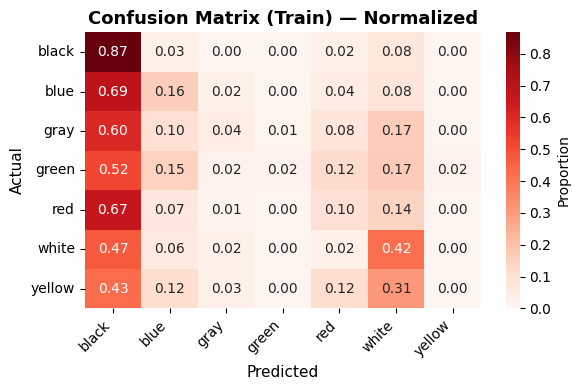

In [49]:
# Standardized confusion matrix
cm = confusion_matrix(y_train, y_pred, labels=labels, normalize="true")

# Heatmap with annotations and colorbar
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Reds",
            xticklabels=labels, yticklabels=labels,
            cbar=True, cbar_kws={'label': 'Proportion'})

plt.title("Confusion Matrix (Train) — Normalized", fontsize=13, fontweight="bold")
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("Actual", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [50]:
print("Accuracy score on train set:")
accuracy_score(y_train, y_pred)

Accuracy score on train set:


0.377541142303969

#### 7.3.2 Test

In [51]:
# Test the logistic regression (L2 - multinomial)
y_pred = reg.predict(X_test)

# Conflusion matrix
labels = list(reg.classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm,
                     index=[f'Actual {c}' for c in labels],
                     columns=[f'Predicted {c}' for c in labels])

# Display the confusion matrix
print("Confusion Matrix (Test):")
cm_df

Confusion Matrix (Test):


,Predicted black,Predicted blue,Predicted gray,Predicted green,Predicted red,Predicted white,Predicted yellow
Actual black,94,1,0,0,6,10,0
Actual blue,28,7,0,0,6,7,0
Actual gray,26,3,2,0,2,6,0
Actual green,12,3,1,0,1,5,0
Actual red,38,7,4,0,4,3,0
Actual white,19,7,3,0,2,13,0
Actual yellow,15,2,1,0,2,5,0


In [52]:
print("Accuracy score on test set:")
accuracy_score(y_test, y_pred)

Accuracy score on test set:


0.34782608695652173

#### 7.3.3. Biais / variance diagnostic

The model achieves 37.75% accuracy on the training set and 34.78% on the test set.
The moderate gap between these values suggests a slight variance, indicating some overfitting but less pronounced than in the logistic regression.

While RIDGE regularization helps reduce overfitting by shrinking coefficients, the overall low accuracy still points to residual bias in the model.
Hence, the Ridge regression strikes a slightly better balance between bias and variance, though its predictive power remains limited.

## 8. Conclusion

The best model is the Ridge regression model, with an accuracy of 37.75% on the training set and 34.78% on the test set (well above random guessing, around 16%).

This means that the Ridge model is able to correctly predict the dominant color of a movie poster in roughly one out of three cases, solely from the film’s metadata such as its genre, budget, language, and year of release.

While this level of accuracy remains moderate, it demonstrates that non-visual features still contain partial but measurable information about the visual identity of a movie poster, making Ridge regression the most effective and reliable approach among all tested models.